<a href="https://colab.research.google.com/github/Kirieshka124/ml_basics/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%968_%D0%9F%D1%80%D0%B8%D0%BC%D0%B5%D0%BD%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D0%BE%D0%B2_%D0%BC%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B4%D0%BB%D1%8F_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8_%D1%82%D0%B5%D0%BA%D1%81%D1%82%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №8. Применение методов машинного обучения для решения задач классификации текстов. Метод Наивного Байеса. Метод опорных векторов**

## Задание 0. Найдите в глобальной сети или соберите свой датасет для классификации текстов (Пример: новости -> рубрики, комментарии в соц. сетях -> характер, )

* Количество классов в датасете должно превышать 2
* Язык текста в датасете: русский

- ### Пример датасетов: [Russian Texts](https://www.kaggle.com/datasets?search=text+classification+russian)

### Загрузите датасет

In [2]:
import kagglehub
import pandas as pd

kagglehub.dataset_download("mikhailma/russian-social-media-text-classification")
df = pd.read_csv('/kaggle/input/russian-social-media-text-classification/train.csv')

df.drop('oid', inplace=True, axis=1)
df.head()

Using Colab cache for faster access to the 'russian-social-media-text-classification' dataset.


,category,text
0,winter_sport,Волшебные фото Виктория Поплавская ЕвгенияМедв...
1,extreme,Возвращение в подземелье Треша 33 Эйфория тупо...
2,football,Лучшие чешские вратари – Доминик Доминатор Гаш...
3,boardgames,Rtokenoid Warhammer40k валрак решил нас подкор...
4,hockey,Шестеркин затаскивает Рейнджерс в финал Восточ...


### Разделите данные на обучающую и валидационную выборки

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['text'], df['category'], test_size = 0.33, random_state = 42)
X_train.shape, X_test.shape

((25955,), (12785,))

### При выполении дальнейших заданий поэксперементируйте с методами векторизации текста:


1. [Bag of Words](https://habr.com/ru/companies/mlclass/articles/270591/) (BOW): Bag of Words представляет текст как вектор, где каждый элемент обозначает количество вхождений конкретного слова в тексте. Процесс включает в себя создание словаря всех уникальных слов в корпусе текстов и подсчет частоты встречаемости каждого слова в отдельных текстах.

2. [TF-IDF](https://habr.com/ru/companies/otus/articles/755772/) (Term Frequency-Inverse Document Frequency): TF-IDF учитывает не только количество вхождений слова в текст, но и частоту его встречаемости в других текстах. Он вычисляет вес слова, умножая его частоту встречаемости (term frequency) на обратную частоту документа (inverse document frequency). Это позволяет снизить вес наиболее часто встречающихся слов, которые могут быть менее информативными.

3. Word Embeddings (например, [Word2Vec](https://habr.com/ru/articles/446530/) и [GloVe](https://jonathan-hui.medium.com/nlp-word-embedding-glove-5e7f523999f6)): Word Embeddings используют нейронные сети для создания векторных представлений слов, которые учитывают семантическую близость между словами. Нейронные сети обучаются на больших текстовых корпусах и захватывают семантические отношения между словами, что позволяет представить слова в векторном пространстве.

4. One-Hot Encoding: One-Hot Encoding преобразует каждое слово в уникальный вектор, где все элементы равны нулю, за исключением одного, который равен единице. Каждый вектор соответствует отдельному слову и используется для представления его в пространстве признаков.

5. [Count Vectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html): Count Vectorizer подсчитывает количество раз, которое каждое слово встречается в тексте. Он создает вектор, в котором каждый элемент соответствует количеству вхождений конкретного слова в текст.

6. [Hashing Vectorizer](https://kavita-ganesan.com/hashingvectorizer-vs-countvectorizer/): Hashing Vectorizer преобразует каждое слово в уникальный числовой идентификатор с помощью хеширования. Он использует хеш-функцию для преобразования слова в числовое значение, которое затем используется в векторном представлении.

7. [Doc2Vec](https://habr.com/ru/articles/599513/): Doc2Vec является расширением метода Word2Vec и позволяет получить векторное представление не только отдельных слов, но и целых документов или текстов. Алгоритм обучает нейронную сеть, которая учитывает контекст и порядок слов в предложении, чтобы получить векторное представление документа. Это позволяет сравнивать и измерять семантическую близость между целыми текстовыми документами.

#### Оцените влияние разных методов на конечный результат

## Задание 1. Обучите модель классификатора Naive Bayes для решения поставленной задачи, используя пайплайн и подбор оптимальных параметров

In [4]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.9 MB/s eta 0:00:00


In [5]:
from sklearn.feature_extraction.text import CountVectorizer, HashingVectorizer
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
import numpy as np

pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', MultinomialNB())
])

param_grid = {
    'vectorizer__ngram_range': [(1, 1), (1, 2)],
    'classifier__alpha': [float(i) for i in np.linspace(start=0.01, stop=10.0, num=20)]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

best_pipeline = grid_search.best_estimator_
display(best_pipeline)
y_pred = best_pipeline.predict(X_test)

Pipeline(steps=[('vectorizer', TfidfVectorizer()),
                ('classifier', MultinomialNB(alpha=0.01))])

### Вывод матрицы ошибок:

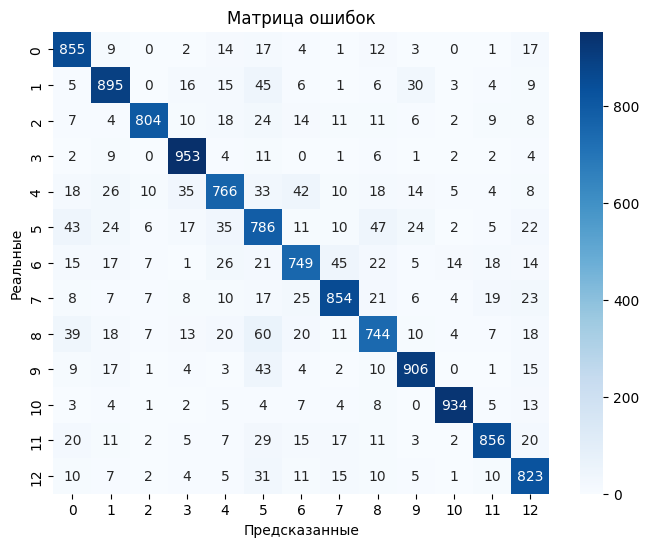

In [6]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".0f", cmap='Blues')
plt.title('Матрица ошибок')
plt.xlabel('Предсказанные')
plt.ylabel('Реальные')
plt.show()

### Оценка точности:

In [7]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print(f"  Accuracy:  {acc:.4f}")

  Accuracy:  0.8545


## Задание 2. Обучите модель SVM (метод опорных векторов) для решения поставленной задачи, используя пайплайны и подбор оптимальных параметров

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', SVC(kernel='rbf'))
])

param_grid = {
    'classifier__C': [float(i) for i in np.linspace(start=0.1, stop=3.0, num=5)],
    'classifier__gamma': ["scale", "auto", [float(i) for i in np.linspace(start=0.1, stop=3.0, num=3)]]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=4, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

best_pipeline = grid_search.best_estimator_
display(best_pipeline)
y_pred = best_pipeline.predict(X_test)

Pipeline(steps=[('vectorizer', TfidfVectorizer()),
                ('classifier', SVC(C=2.275))])

### Вывод матрицы ошибок:

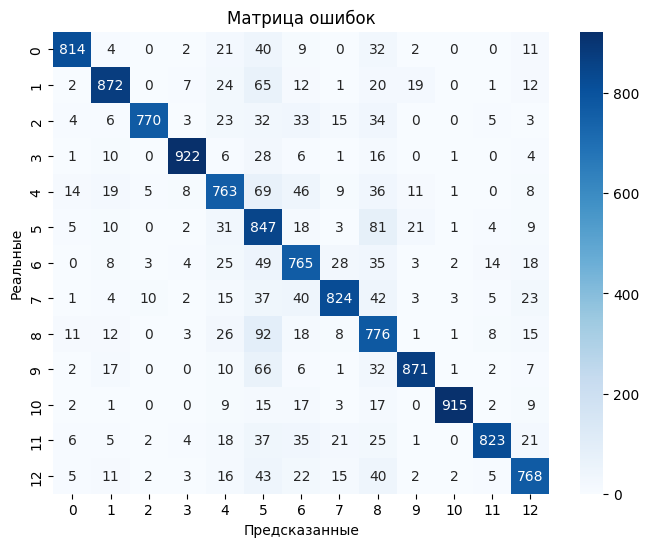

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".0f", cmap='Blues')
plt.title('Матрица ошибок')
plt.xlabel('Предсказанные')
plt.ylabel('Реальные')
plt.show()

### Оценка точности:

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print(f"  Accuracy:  {acc:.4f}")

  Accuracy:  0.8393


## Задание 3. Обучите модель классификатора Decision Tree Classifier для решения поставленной задачи

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer

pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', DecisionTreeClassifier(random_state=42))
])



pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

### Вывод матрицы ошибок:

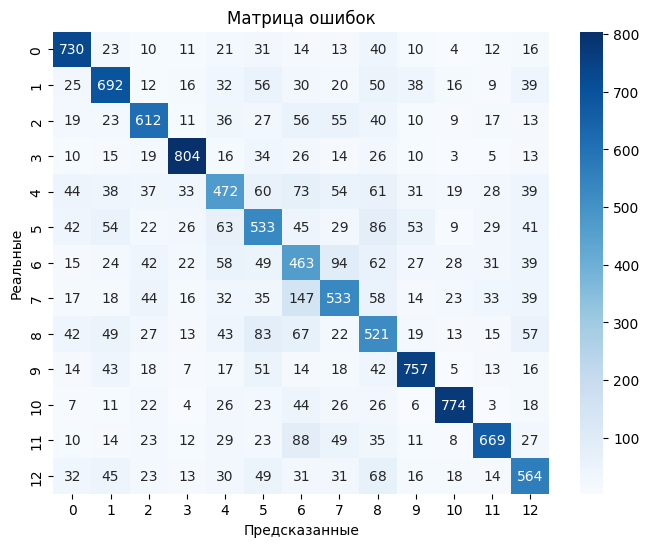

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".0f", cmap='Blues')
plt.title('Матрица ошибок')
plt.xlabel('Предсказанные')
plt.ylabel('Реальные')
plt.show()

### Оценка точности:

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print(f"  Accuracy:  {acc:.4f}")

  Accuracy:  0.6354


## Задание 4. Обучите модель классификатора Random Forest Classifier для решения поставленной задачи

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer

pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', RandomForestClassifier(random_state=42))
])

max_depth = [int(i) for i in np.linspace(start=1, stop=80, num=4)]
max_depth.append(None)
param_grid = {
    'classifier__n_estimators': [int(x) for x in np.linspace(start=10, stop=300, num=4)],
    'classifier__max_depth': max_depth
}

grid_search = GridSearchCV(pipeline, param_grid, cv=4, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

best_pipeline = grid_search.best_estimator_
display(best_pipeline)
y_pred = best_pipeline.predict(X_test)

Fitting 4 folds for each of 20 candidates, totalling 80 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Pipeline(steps=[('vectorizer', TfidfVectorizer()),
                ('classifier',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

### Вывод матрицы ошибок:

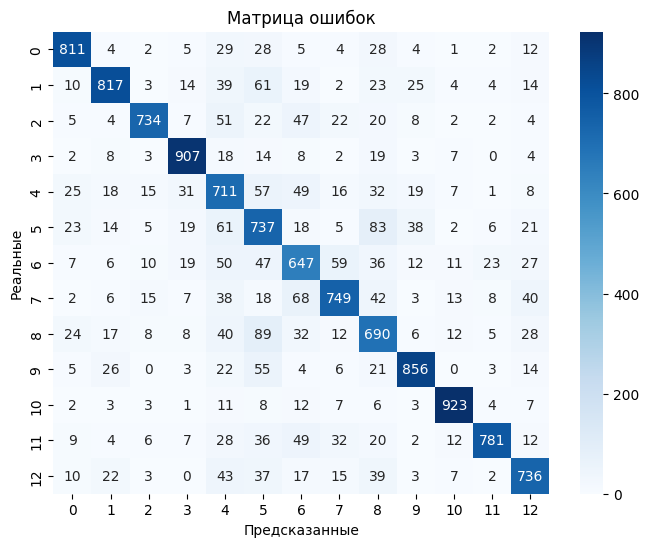

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".0f", cmap='Blues')
plt.title('Матрица ошибок')
plt.xlabel('Предсказанные')
plt.ylabel('Реальные')
plt.show()

### Оценка точности:

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print(f"  Accuracy:  {acc:.4f}")

  Accuracy:  0.7899


## Подведите общие итоги и сделайте выводы

Можно заметить, что наилучшей моделью стала модель Наивного Байеса (Accuracy:  0.8545).

 Если бы с SVM (Accuracy:  0.8393) был проведен более хороший перебор гиперпараметров, то эта модель наверняка сравнялась бы в точности с моделью Наивного Байеса.

 Модель Random Forest (Accuracy:  0.7899) оказалась на третьем месте, если проводить и дальше подбор гиперпараметров, то результат будет лучше.

 Наихудшей оказалась модель Дерева решений (Accuracy:  0.6354), даже с попытками подбора она показывала худшие результаты.